# Import

In [2]:
%pip install qiskit
%pip install qiskit_machine_learning
%pip install qiskit_algorithms

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl

from numpy import linalg
from qiskit_machine_learning.datasets import ad_hoc_data
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import Sampler
from qiskit_algorithms.state_fidelities import ComputeUncompute

# Kernels

In [4]:
def sigmoid_kernel(x1, x2, alpha=1, c=0):
    return np.tanh(alpha * np.dot(x1, x2) + c)

def laplacian_kernel(x, y, sigma=1.0):
    return np.exp(-linalg.norm(x - y) / sigma)

def anova_kernel(x, y, D):
    return sum(np.prod(np.outer(x[:d], y[:d])) for d in range(D + 1))

def chi_squared_kernel(x, y):
    return np.exp(-np.sum((x - y)**2 / (x + y)))

def histogram_intersection_kernel(x, y):
    return np.sum(np.minimum(x, y))

def linear_kernel(x1, x2):
    return np.dot(x1, x2)

def polynomial_kernel(x, y, p=3):
    return (1 + np.dot(x, y)) ** p

def gaussian_kernel(x, y, sigma=5.0):
    return np.exp(-linalg.norm(x-y)**2 / (2 * (sigma ** 2)))

def rbf_kernel(x, y, gamma=0.1):
    return np.exp(-gamma * linalg.norm(x - y)**2)


# Perceptron

In [5]:
class Perceptron(object):

    def __init__(self, T=1):
        self.T = T

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float64)
        self.b = 0.0

        for t in range(self.T):
            for i in range(n_samples):
                if self.predict(X[i])[0] != y[i]:
                    self.w += y[i] * X[i]
                    self.b += y[i]

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        X = np.atleast_2d(X)
        return np.sign(self.project(X))

# Kernel Perceptron

In [6]:
class KernelPerceptron(object):

    def __init__(self, kernel, T=1):
        self.kernel = kernel
        self.T = T

    def fit(self, X, y):
        n_samples, _ = X.shape
        self.alpha = np.zeros(n_samples, dtype=np.float64)

        # Gram matrix
        K = np.zeros((n_samples, n_samples))
        for i in range(n_samples):
            for j in range(n_samples):
                K[i,j] = self.kernel(X[i], X[j])

        for _ in range(self.T):
            for i in range(n_samples):
                if np.sign(np.sum(K[:,i] * self.alpha * y)) != y[i]:
                    self.alpha[i] += 1.0

        # Support vectors
        sv = self.alpha > 1e-5
        self.alpha = self.alpha[sv]
        self.sv = X[sv]
        self.sv_y = y[sv]
        print(f"{len(self.alpha)} support vectors out of {n_samples} points")

    def project(self, X):
        y_predict = np.zeros(len(X))
        for i in range(len(X)):
            s = 0
            for a, sv_y, sv in zip(self.alpha, self.sv_y, self.sv):
                s += a * sv_y * self.kernel(X[i], sv)
            y_predict[i] = s
        return y_predict

    def predict(self, X):
        X = np.atleast_2d(X)
        return np.sign(self.project(X))

# Dataset

## Simple

https://gist.github.com/mblondel/656147

In [7]:
def gen_lin_separable_data():
    # generate training data in the 2-d case
    mean1 = np.array([0, 2])
    mean2 = np.array([2, 0])
    cov = np.array([[0.8, 0.6], [0.6, 0.8]])
    X1 = np.random.multivariate_normal(mean1, cov, 100)
    y1 = np.ones(len(X1))
    X2 = np.random.multivariate_normal(mean2, cov, 100)
    y2 = np.ones(len(X2)) * -1
    return X1, y1, X2, y2

def gen_non_lin_separable_data():
    mean1 = [-1, 2]
    mean2 = [1, -1]
    mean3 = [4, -4]
    mean4 = [-4, 4]
    cov = [[1.0,0.8], [0.8, 1.0]]
    X1 = np.random.multivariate_normal(mean1, cov, 50)
    X1 = np.vstack((X1, np.random.multivariate_normal(mean3, cov, 50)))
    y1 = np.ones(len(X1))
    X2 = np.random.multivariate_normal(mean2, cov, 50)
    X2 = np.vstack((X2, np.random.multivariate_normal(mean4, cov, 50)))
    y2 = np.ones(len(X2)) * -1
    return X1, y1, X2, y2

def gen_lin_separable_overlap_data():
    # generate training data in the 2-d case
    mean1 = np.array([0, 2])
    mean2 = np.array([2, 0])
    cov = np.array([[1.5, 1.0], [1.0, 1.5]])
    X1 = np.random.multivariate_normal(mean1, cov, 100)
    y1 = np.ones(len(X1))
    X2 = np.random.multivariate_normal(mean2, cov, 100)
    y2 = np.ones(len(X2)) * -1
    return X1, y1, X2, y2

def split_train(X1, y1, X2, y2):
    X1_train = X1[:90]
    y1_train = y1[:90]
    X2_train = X2[:90]
    y2_train = y2[:90]
    X_train = np.vstack((X1_train, X2_train))
    y_train = np.hstack((y1_train, y2_train))
    return X_train, y_train

def split_test(X1, y1, X2, y2):
    X1_test = X1[90:]
    y1_test = y1[90:]
    X2_test = X2[90:]
    y2_test = y2[90:]
    X_test = np.vstack((X1_test, X2_test))
    y_test = np.hstack((y1_test, y2_test))
    return X_test, y_test

def plot_margin(X1_train, X2_train, clf):
    def f(x, w, b, c=0):
        # given x, return y such that [x,y] in on the line
        # w.x + b = c
        return (-w[0] * x - b + c) / w[1]

    pl.plot(X1_train[:,0], X1_train[:,1], "ro")
    pl.plot(X2_train[:,0], X2_train[:,1], "bo")

    # w.x + b = 0
    a0 = -4; a1 = f(a0, clf.w, clf.b)
    b0 = 4; b1 = f(b0, clf.w, clf.b)
    pl.plot([a0,b0], [a1,b1], "k")

    pl.axis("tight")
    pl.show()

def plot_contour(X1_train, X2_train, clf):
    pl.plot(X1_train[:,0], X1_train[:,1], "ro")
    pl.plot(X2_train[:,0], X2_train[:,1], "bo")
    pl.scatter(clf.sv[:,0], clf.sv[:,1], s=100, c="g")

    X1, X2 = np.meshgrid(np.linspace(-6,6,50), np.linspace(-6,6,50))
    X = np.array([[x1, x2] for x1, x2 in zip(np.ravel(X1), np.ravel(X2))])
    Z = clf.project(X).reshape(X1.shape)
    pl.contour(X1, X2, Z, [0.0], colors='k', linewidths=1, origin='lower')

    pl.axis("tight")
    pl.show()

def test_linear(T=3):
    X1, y1, X2, y2 = gen_lin_separable_data()
    #X1, y1, X2, y2 = gen_lin_separable_overlap_data()
    X_train, y_train = split_train(X1, y1, X2, y2)
    X_test, y_test = split_test(X1, y1, X2, y2)

    clf = Perceptron(T=T)
    clf.fit(X_train, y_train)

    y_predict = clf.predict(X_test)
    correct = np.sum(y_predict == y_test)
    print(f"{correct} out of {len(y_predict)} predictions correct")

    plot_margin(X_train[y_train==1], X_train[y_train==-1], clf)

def test_kernel(kernel, T=20):
    X1, y1, X2, y2 = gen_non_lin_separable_data()
    X_train, y_train = split_train(X1, y1, X2, y2)
    X_test, y_test = split_test(X1, y1, X2, y2)

    clf = KernelPerceptron(kernel, T=T)
    clf.fit(X_train, y_train)

    y_predict = clf.predict(X_test)
    correct = np.sum(y_predict == y_test)
    print(f"{correct} out of {len(y_predict)} predictions correct")

    plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

20 out of 20 predictions correct


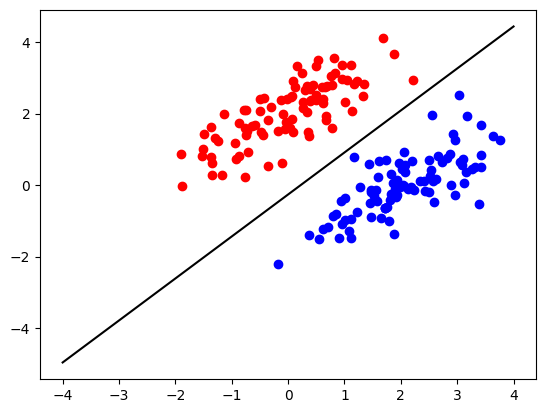

In [8]:
test_linear()

6 support vectors out of 180 points
20 out of 20 predictions correct


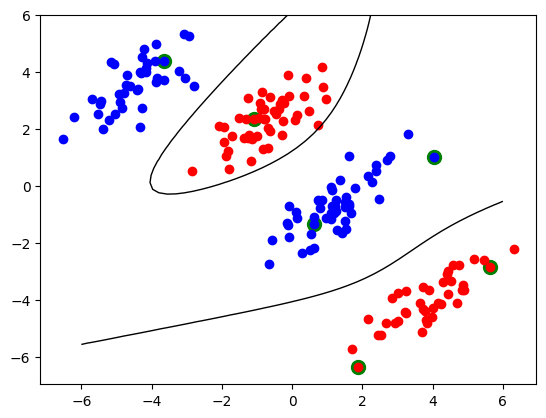

In [9]:
test_kernel(rbf_kernel)

36 support vectors out of 180 points
10 out of 20 predictions correct


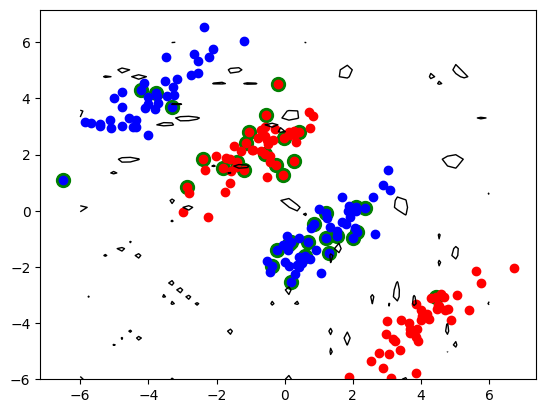

In [11]:
adhoc_feature_map = ZZFeatureMap(feature_dimension=2, reps=2, entanglement="linear")
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)
quantum_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=adhoc_feature_map)

test_kernel(quantum_kernel.evaluate)

## Adhoc

In [ ]:
adhoc_dimension = 2
X_train, y_train, X_test, y_test, adhoc_total = ad_hoc_data(
    training_size=20,
    test_size=5,
    n=adhoc_dimension,
    gap=0.3,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

In [ ]:
def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    # A train plot
    ax.scatter(
        # x coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 0],
        # y coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
    )


def plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total):

    plt.figure(figsize=(5, 5))
    plt.ylim(0, 2 * np.pi)
    plt.xlim(0, 2 * np.pi)
    plt.imshow(
        np.asmatrix(adhoc_total).T,
        interpolation="nearest",
        origin="lower",
        cmap="RdBu",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
    )

    # A train plot
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A train")

    # B train plot
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B train")

    # A test plot
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")

    # B test plot
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.title("Ad hoc dataset")

    plt.show()

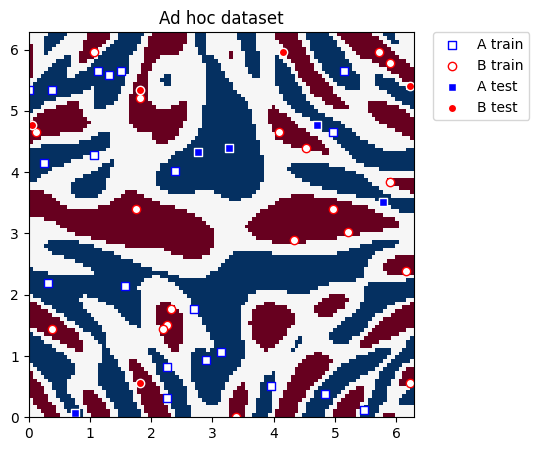

In [ ]:
plot_dataset(X_train, y_train, X_test, y_test, adhoc_total)

In [ ]:
adhoc_feature_map = ZZFeatureMap(feature_dimension=adhoc_dimension, reps=2, entanglement="linear")
sampler = Sampler()
fidelity = ComputeUncompute(sampler=sampler)
adhoc_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=adhoc_feature_map)

21 support vectors out of 40 points
5 out of 10 predictions correct


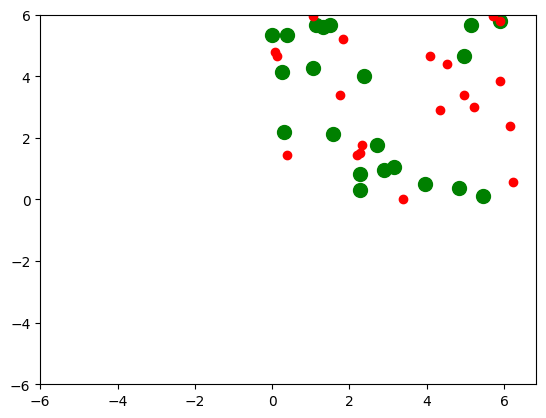

In [ ]:
clf = KernelPerceptron(kernel=adhoc_kernel.evaluate, T=40)
clf.fit(X_train, y_train)

y_predict = clf.predict(X_test)
correct = np.sum(y_predict == y_test)
print(f"{correct} out of {len(y_predict)} predictions correct")

plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

21 support vectors out of 40 points
5 out of 10 predictions correct


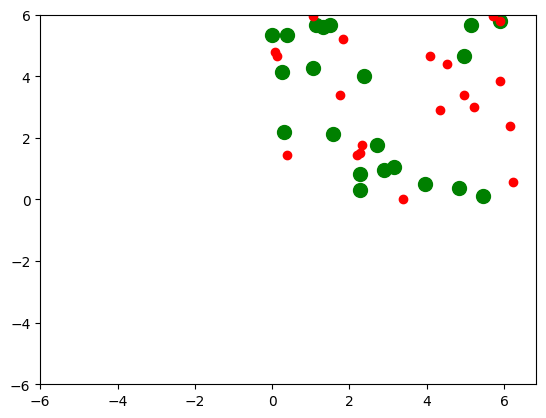

In [ ]:
clf = KernelPerceptron(kernel=gaussian_kernel, T=40)
clf.fit(X_train, y_train)

y_predict = clf.predict(X_test)
correct = np.sum(y_predict == y_test)
print(f"{correct} out of {len(y_predict)} predictions correct")

plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

5 out of 10 predictions correct


AttributeError: 'Perceptron' object has no attribute 'sv'

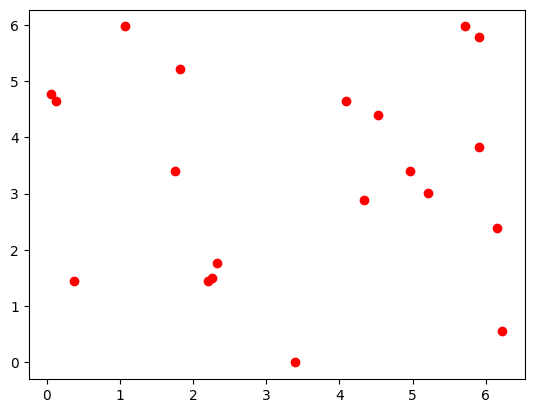

In [ ]:
clf = Perceptron(T=40)
clf.fit(X_train, y_train)

y_predict = clf.predict(X_test)
correct = np.sum(y_predict == y_test)
print(f"{correct} out of {len(y_predict)} predictions correct")

plot_contour(X_train[y_train==1], X_train[y_train==-1], clf)

# MLP

In [ ]:
class Perceptron(object):

    def __init__(self, input_features, output_size, T=1):
        self.input_features = input_features
        self.output_size = 

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float64)
        self.b = 0.0

        for t in range(self.T):
            for i in range(n_samples):
                if self.predict(X[i])[0] != y[i]:
                    self.w += y[i] * X[i]
                    self.b += y[i]

    def project(self, X):
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        X = np.atleast_2d(X)
        return np.sign(self.project(X))